#### shapes 이미지 학습시켜서 예측하기

In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import load_img, img_to_array

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

#### ImageDataGenerator

In [ ]:
# dataGen = ImageDataGenerator( rescale= 1. / 255 )
dataGen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, vertical_flip=True, 
                            shear_range=0.5, 
                            brightness_range=[0.5,1.5], zoom_range=0.2,
                            width_shift_range=0.1, height_shift_range=0.1,
                            rotation_range=30, fill_mode='nearest' )
imgGen = dataGen.flow_from_directory('./shapes', target_size = (100,100))
imgGen.class_indices

Found 14970 images belonging to 4 classes.


{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

In [3]:
imgGen.image_shape

(100, 100, 3)

#### CNN

In [ ]:
model = Sequential()
model.add( Conv2D( 64, kernel_size=(2,2),
                    input_shape=(100,100,3), activation='relu') )
model.add( MaxPool2D( pool_size=(2,2) ) )
model.add( Conv2D( 32, kernel_size=(3,3), activation='relu' ) )
model.add( MaxPool2D( pool_size=(2,2)) )

model.add( Flatten() )
model.add( Dense(units=64, activation='relu') )
model.add( Dense(units=32, activation='relu') )
model.add( Dense(units=4, activation='softmax') )

model.compile( loss='categorical_crossentropy', optimizer='adam', metrics=['acc'] )
model.fit(imgGen, epochs=5)

c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - acc: 0.8641 - loss: 0.3118
Epoch 2/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - acc: 0.9908 - loss: 0.0288
Epoch 3/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - acc: 0.9939 - loss: 0.0196
Epoch 4/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - acc: 0.9975 - loss: 0.0076
Epoch 5/5
468/468 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - acc: 0.9980 - loss: 0.0065


In [9]:
model.save('shapes(augment).keras')

#### 예측 확인

In [5]:
imgGen.class_indices

{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

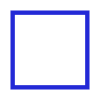

In [7]:
s_img = load_img('./image/square.jpg', target_size=(100,100))
s_img

In [ ]:
imgArr = img_to_array(s_img) /255

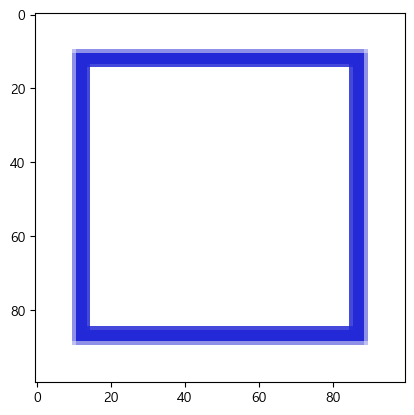

In [ ]:
plt.imshow(imgArr)
plt.show()

In [ ]:
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([1])